# Training process: unsmoothed and smoothed model

This notebook visualizes the training process for the two brain age models: one trained on unsmoothed asymmetry maps and one trained on smoothed asymmetry maps from healthy subjects. Else, the models are identical.

The purpose is to inspect how the training loss, validation loss and validation MAE changed across epochs.

In [1]:
# Import packages 
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Use consistent figure size and font size for all plots 
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["font.size"] = 11

## Unsmoothed model

In [2]:
# Path to the CSV file containing the logged training metrics for each epoch
csv_file = Path("/Users/anneaasengen/MS_project/train_epochs.csv")

In [3]:
# Training details for the unsmoothed model
# The file contains one row per epoch, including training loss, validation loss and validation MAE
df = pd.read_csv(csv_file, sep=";")

df.head()

,epoch,train_loss,valid_loss,mae,time
0,0,18.322073,16.631496,16.631496,01:39
1,1,16.592052,16.701021,16.701021,01:40
2,2,15.093497,15.111836,15.111836,01:42
3,3,14.005088,13.866008,13.866008,01:40
4,4,11.909065,12.184627,12.184627,01:40


In [4]:
# The lowest val MAE was observed at epoch 230 for the unsmoothed model
best_epoch = 230

# Extract the row containing the metrics from the best epoch
best_row = df[df["epoch"] == best_epoch].iloc[0]

print(best_row)

epoch              230
train_loss    1.426384
valid_loss    5.524301
mae           5.524301
time             01:40
Name: 230, dtype: object


### Plot: Training and validation loss across epochs

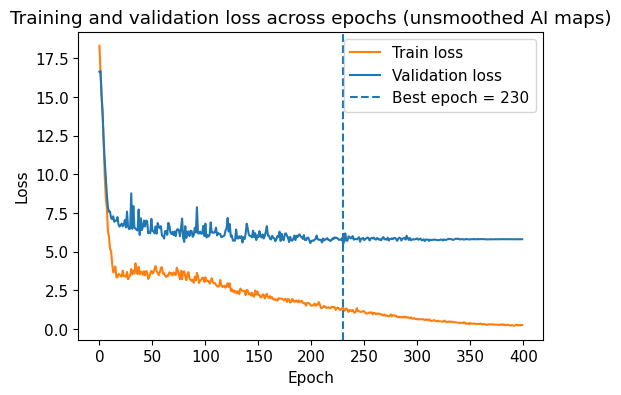

In [5]:
# Plot the training and validation loss to inspect model convergence
plt.figure()

plt.plot(df["epoch"], df["train_loss"], label="Train loss", color="tab:orange")
plt.plot(df["epoch"], df["valid_loss"], label="Validation loss", color="tab:blue")

# Mark the epoch with the best validation MAE
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss across epochs (unsmoothed AI maps)")
plt.legend()

#plt.savefig("train_val_loss.png", dpi=300, bbox_inches="tight") # save figure as png
plt.show()

### Plot: Validation MAE across epochs

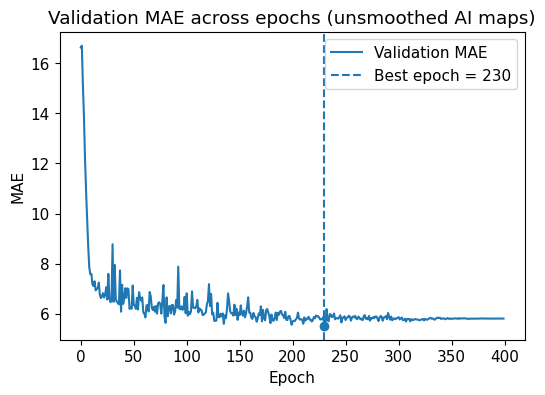

In [6]:
# Plot the validation MAE across epochs
# MAE is the main performance metric because the task is age regression
plt.figure()

plt.plot(df["epoch"], df["mae"], label="Validation MAE")

# Highlight the selected checkpoint
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")
plt.scatter(best_epoch, best_row["mae"], zorder=3)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Validation MAE across epochs (unsmoothed AI maps)")
plt.legend()

#plt.savefig("val_mae.png", dpi=300, bbox_inches="tight")
plt.show()

## Smoothed model

In [7]:
# Training details for the smoothed model
smoothed_csv_file = Path("/Users/anneaasengen/MS_project/smoothed_train_epochs.csv")

In [8]:
# Training details for the smoothed model
# The file contains one row per epoch, including training loss, validation loss and validation MAE
df_smooth = pd.read_csv(smoothed_csv_file, sep=";")

df_smooth.head()

,epoch,train_loss,valid_loss,mae,time
0,0,17.671053,15.805129,15.805129,01:40
1,1,14.305138,13.942862,13.942862,01:40
2,2,12.897684,11.835806,11.835806,01:42
3,3,10.756629,11.212151,11.212151,01:40
4,4,9.828721,10.170674,10.170674,01:41


In [9]:
# The lowest val MAE was observed at epoch 235 for the smoothed model
smooth_best_epoch = 235

# Extract the metrics from the selected epoch
smooth_best_row = df_smooth[df_smooth["epoch"] == smooth_best_epoch].iloc[0]

print(smooth_best_row)

epoch              235
train_loss    1.284024
valid_loss    6.847828
mae           6.847828
time             01:41
Name: 235, dtype: object


### Plot: Training and validation loss across epochs

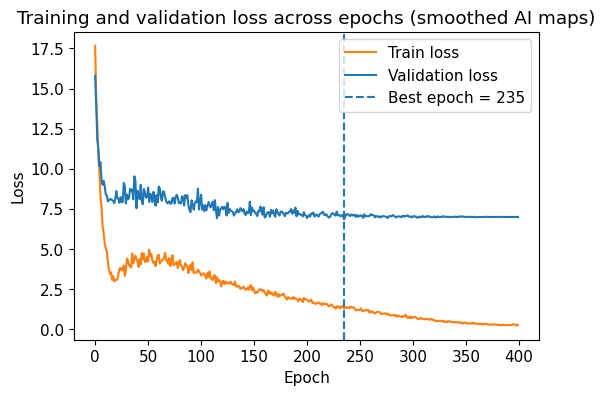

In [10]:
# Plot the training and validation loss for the smoothed model
plt.figure()

plt.plot(df_smooth["epoch"], df_smooth["train_loss"], label="Train loss", color="tab:orange")
plt.plot(df_smooth["epoch"], df_smooth["valid_loss"], label="Validation loss", color="tab:blue")

# Mark the epoch with the best validation MAE
plt.axvline(smooth_best_epoch, linestyle="--", label=f"Best epoch = {smooth_best_epoch}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss across epochs (smoothed AI maps)")
plt.legend()

#plt.savefig("smooth_train_val_loss.png", dpi=300, bbox_inches="tight")
plt.show()

### Plot: Validation MAE across epochs

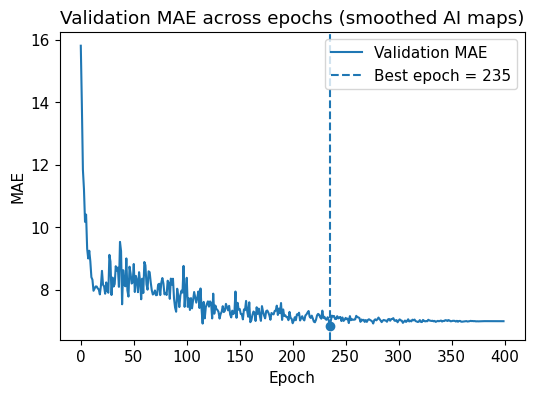

In [11]:
# Plot the validation MAE for the smoothed model
# This shows when the model achieved its best validation performance
plt.figure()

plt.plot(df_smooth["epoch"], df_smooth["mae"], label="Validation MAE")

# Highlight the selected checkpoint
plt.axvline(smooth_best_epoch, linestyle="--", label=f"Best epoch = {smooth_best_epoch}")
plt.scatter(smooth_best_epoch, smooth_best_row["mae"], zorder=3)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Validation MAE across epochs (smoothed AI maps)")
plt.legend()

#plt.savefig("smooth_val_mae.png", dpi=300, bbox_inches="tight")
plt.show()